In [1]:
import pandas as pd

# Load the datasets
base_interest_df = pd.read_csv('yearly-amount-of-base-interest-credited-to-cpf-members.csv')
extra_interest_df = pd.read_csv('yearly-amount-of-extra-interest-credited-to-cpf-members.csv')

# Inspect the data
print("Base Interest DataFrame:")
print(base_interest_df.head())
print(base_interest_df.info())

print("\nExtra Interest DataFrame:")
print(extra_interest_df.head())
print(extra_interest_df.info())

Base Interest DataFrame:
     yr  interest_amt
0  2006    3926800000
1  2007    4228000000
2  2008    4644100000
3  2009    5215300000
4  2010    5772300000
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   yr            15 non-null     int64
 1   interest_amt  15 non-null     int64
dtypes: int64(2)
memory usage: 372.0 bytes
None

Extra Interest DataFrame:
     yr  interest_amt
0  2008     811000000
1  2009     877300000
2  2010     937500000
3  2011    1001200000
4  2012    1091000000
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   yr            13 non-null     int64
 1   interest_amt  13 non-null     int64
dtypes: int64(2)
memory usage: 340.0 bytes
None


Merged DataFrame:
      yr  interest_amt_base  interest_amt_extra  total_interest  \
0   2008         4644100000           811000000      5455100000   
1   2009         5215300000           877300000      6092600000   
2   2010         5772300000           937500000      6709800000   
3   2011         6471500000          1001200000      7472700000   
4   2012         7199600000          1091000000      8290600000   
5   2013         8028800000          1115400000      9144200000   
6   2014         8814000000          1157900000      9971900000   
7   2015         9634700000          1199800000     10834500000   
8   2016        10571300000          1476900000     12048200000   
9   2017        11647900000          1548300000     13196200000   
10  2018        12734700000          1615500000     14350200000   
11  2019        13892900000          1681500000     15574400000   
12  2020        15116200000          1748600000     16864800000   

    pct_change_base  pct_change_extra  pct_

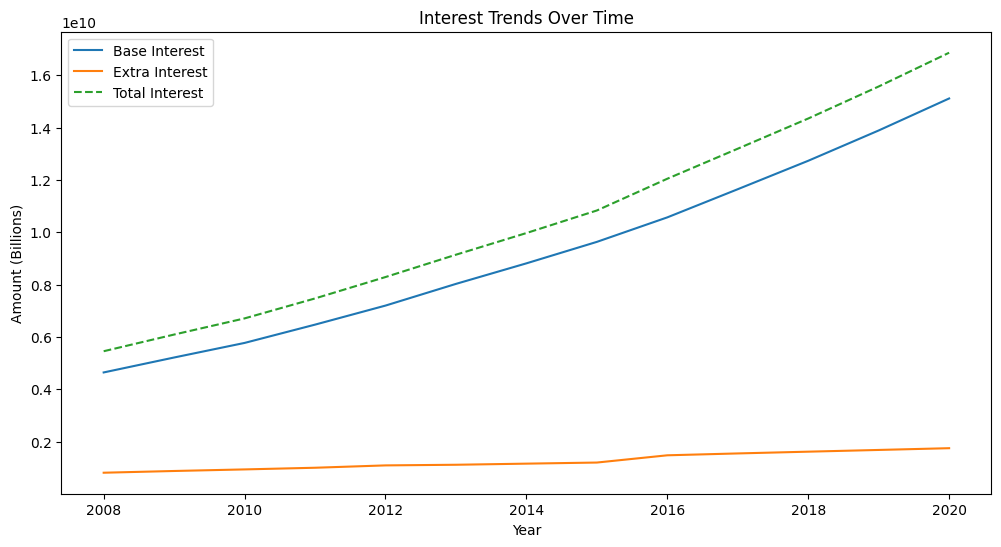

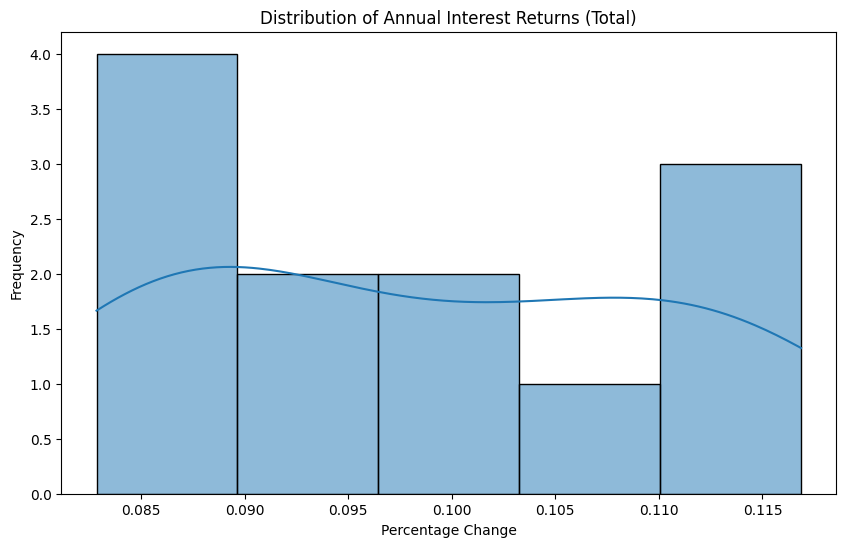

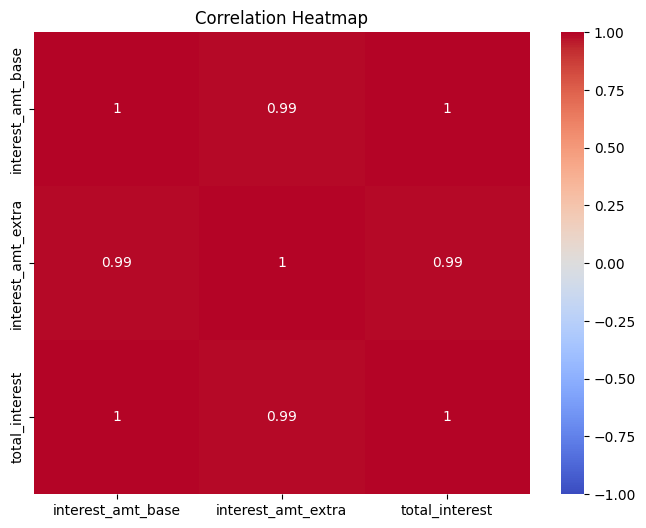

In [2]:
# Merge the dataframes
merged_df = pd.merge(base_interest_df, extra_interest_df, on='yr', suffixes=('_base', '_extra'))

# Calculate total interest (Price Volume)
merged_df['total_interest'] = merged_df['interest_amt_base'] + merged_df['interest_amt_extra']

# Calculate Returns (Percentage Change)
merged_df['pct_change_base'] = merged_df['interest_amt_base'].pct_change()
merged_df['pct_change_extra'] = merged_df['interest_amt_extra'].pct_change()
merged_df['pct_change_total'] = merged_df['total_interest'].pct_change()

# Calculate Correlation
correlation_matrix = merged_df[['interest_amt_base', 'interest_amt_extra', 'total_interest']].corr()

print("Merged DataFrame:")
print(merged_df)
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Save to CSV for the user
merged_df.to_csv('merged_interest_data.csv', index=False)
correlation_matrix.to_csv('correlation_matrix.csv')

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Trends
plt.figure(figsize=(12, 6))
plt.plot(merged_df['yr'], merged_df['interest_amt_base'], label='Base Interest')
plt.plot(merged_df['yr'], merged_df['interest_amt_extra'], label='Extra Interest')
plt.plot(merged_df['yr'], merged_df['total_interest'], label='Total Interest', linestyle='--')
plt.title('Interest Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Amount (Billions)')
plt.legend()
plt.savefig('interest_trends.png')

# Plot Return Distribution
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['pct_change_total'].dropna(), kde=True)
plt.title('Distribution of Annual Interest Returns (Total)')
plt.xlabel('Percentage Change')
plt.ylabel('Frequency')
plt.savefig('return_distribution.png')

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

     yr  interest_amt_base  interest_amt_extra  interest_total  return_base  \
0  2008         4644100000           811000000      5455100000          NaN   
1  2009         5215300000           877300000      6092600000     0.122995   
2  2010         5772300000           937500000      6709800000     0.106801   
3  2011         6471500000          1001200000      7472700000     0.121130   
4  2012         7199600000          1091000000      8290600000     0.112509   

   return_extra  return_total  
0           NaN           NaN  
1      0.081751      0.116863  
2      0.068620      0.101303  
3      0.067947      0.113699  
4      0.089692      0.109452  
Correlation Matrix:
                    interest_amt_base  interest_amt_extra  interest_total
interest_amt_base            1.000000            0.987212        0.999904
interest_amt_extra           0.987212            1.000000        0.989324
interest_total               0.999904            0.989324        1.000000


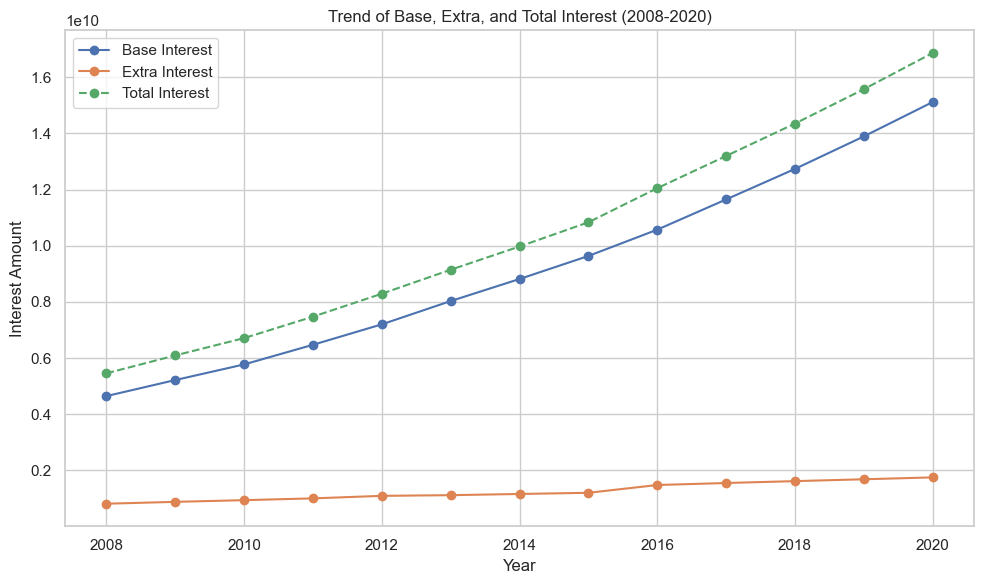

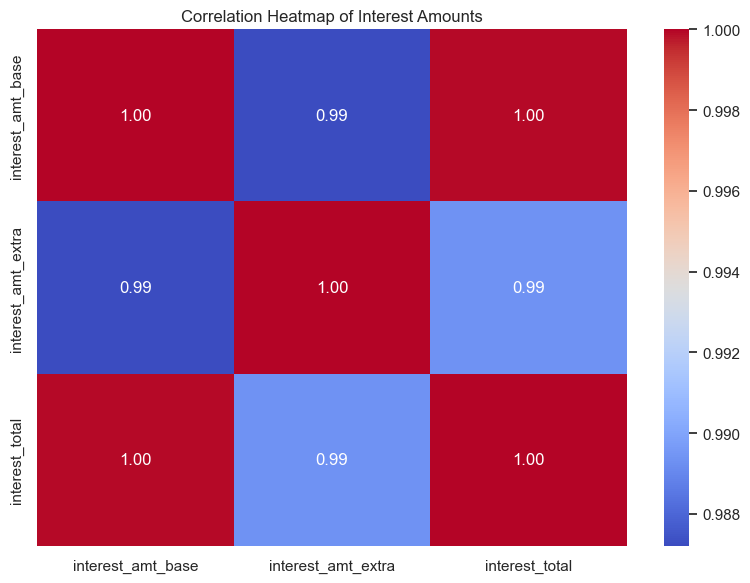

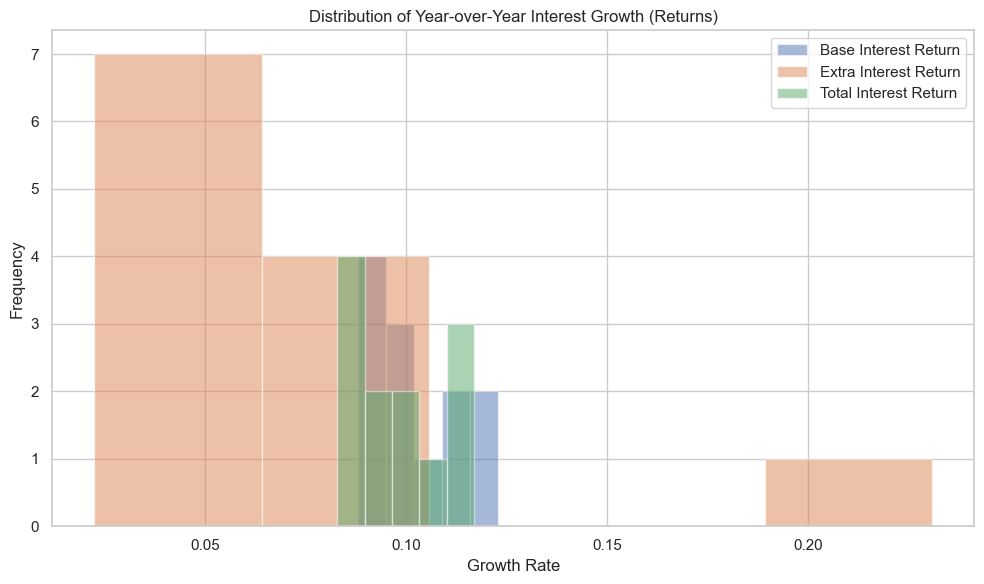

In [3]:
# Merge the dataframes
df = pd.merge(base_interest_df, extra_interest_df, on='yr', suffixes=('_base', '_extra'))

# Calculate Total Interest
df['interest_total'] = df['interest_amt_base'] + df['interest_amt_extra']

# Calculate Return (Year-over-Year Percentage Change)
df['return_base'] = df['interest_amt_base'].pct_change()
df['return_extra'] = df['interest_amt_extra'].pct_change()
df['return_total'] = df['interest_total'].pct_change()

# Display the merged dataframe
print(df.head())

# Save to CSV for the user
df.to_csv("processed_interest_data.csv", index=False)

# Correlation matrix
corr_matrix = df[['interest_amt_base', 'interest_amt_extra', 'interest_total']].corr()
print("Correlation Matrix:")
print(corr_matrix)

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# 1. Price Trend (Interest Amounts over time)
plt.figure(figsize=(10, 6))
plt.plot(df['yr'], df['interest_amt_base'], label='Base Interest', marker='o')
plt.plot(df['yr'], df['interest_amt_extra'], label='Extra Interest', marker='o')
plt.plot(df['yr'], df['interest_total'], label='Total Interest', marker='o', linestyle='--')
plt.title('Trend of Base, Extra, and Total Interest (2008-2020)')
plt.xlabel('Year')
plt.ylabel('Interest Amount')
plt.legend()
plt.tight_layout()
plt.savefig('interest_trends.png')

# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Interest Amounts')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

# 3. Return Distribution
plt.figure(figsize=(10, 6))
# Dropping NaN from pct_change()
plt.hist(df['return_base'].dropna(), bins=5, alpha=0.5, label='Base Interest Return')
plt.hist(df['return_extra'].dropna(), bins=5, alpha=0.5, label='Extra Interest Return')
plt.hist(df['return_total'].dropna(), bins=5, alpha=0.5, label='Total Interest Return')
plt.title('Distribution of Year-over-Year Interest Growth (Returns)')
plt.xlabel('Growth Rate')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('return_distribution.png')